# Section 1 - Importation de tirage


In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import shap
import statsmodels.api as sm

# Définir les bornes de colonnes
col_start = 1   # [ 2025(1) - 2034(10) ]  [ 2025(11) - 2044(20) ]
col_end   = 43  # correspond à la colonne 11

# Fonction de extraction des données historiques

In [ ]:
def load_matrix_from_excel(filename, sheet_name, print_title="data_array shape"):
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_excel(filename, sheet_name=sheet_name, header=None)

    df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
    df = df.iloc[1:].reset_index(drop=True)

    # Extraire les colonnes BE et PVFP
    date_array = df.iloc[:, 0].values
    data_array = df.iloc[:, 1].values

    # Affichage complet des DataFrames
    #print(df.head())
    print("Shape du fichier :", df.shape)
    print("date_array.shape :\n", date_array.shape)
    print(f"{print_title} :\n", data_array.shape)

    return date_array, data_array

# Extraction TEC 10ans jusuq'à 2004

In [ ]:
date_array, tec_array = load_matrix_from_excel("TEC10_bis.xlsx", "TEC10_", print_title="TEC10_array shape")

Saving TEC10_bis.xlsx to TEC10_bis.xlsx
Shape du fichier : (7699, 2)
date_array.shape :
 (7699,)
TEC10_array shape :
 (7699,)


# Extraction de TEC10ans Monthly

In [ ]:
date_array, tec_array = load_matrix_from_excel("TEC10_V3.xlsx", "TEC10_ME", print_title="TEC10_2025_array shape")

Saving TEC10_V3.xlsx to TEC10_V3.xlsx
Shape du fichier : (248, 2)
date_array.shape :
 (248,)
TEC10_2025_array shape :
 (248,)


# Extraction de inflation france

In [ ]:
date_inf_array, inflation_array = load_matrix_from_excel("Inflation_Y.xlsx", "Inflation_Y", print_title="inflation_array shape")

Saving Inflation_Y.xlsx to Inflation_Y.xlsx
Shape du fichier : (65, 6)
date_array.shape :
 (65,)
inflation_array shape :
 (65,)


# Série temporelle - stationnaire

Création d'une série temporelle avec Datetime

             TEC10
date              
2004-11-30  0.0381
2004-12-31  0.0371
2005-01-31  0.0356
2005-02-28   0.037
2005-03-31  0.0367
Moyenne stationnaire : 0.021652862903225795
Écart-type stationnaire : 0.01486701839307925


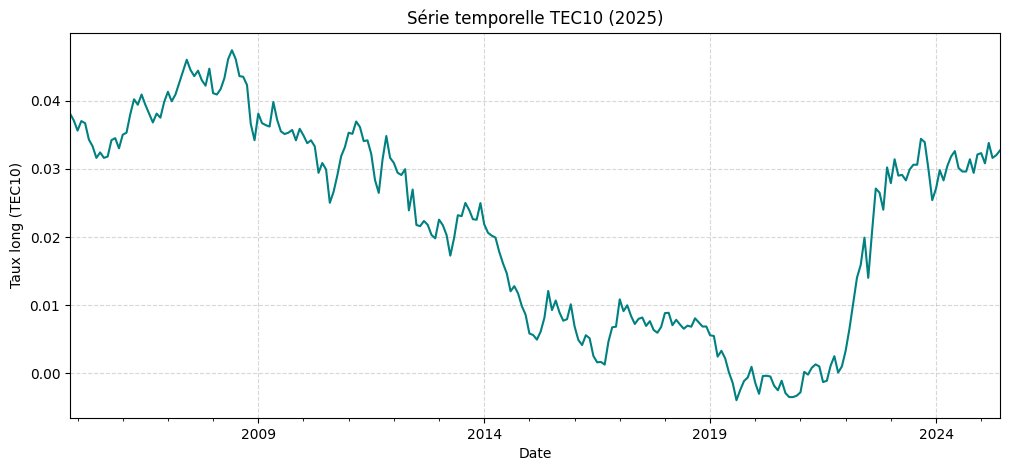

In [ ]:
# Construire un DataFrame avec tes arrays
ts_df = pd.DataFrame({
    "date": date_array,
    "TEC10": tec_array
})

# Convertir en datetime (si ce n'est pas déjà le cas)
ts_df["date"] = pd.to_datetime(ts_df["date"])

# Mettre la date comme index
ts_df = ts_df.set_index("date")

# Afficher la série temporelle
print(ts_df.head())

# Calculer la moyenne stationnaire (moyenne historique)
mean_stationnaire = ts_df["TEC10"].mean()
std_stationnaire = ts_df["TEC10"].std()

print("Moyenne stationnaire :", mean_stationnaire)
print("Écart-type stationnaire :", std_stationnaire)

# Tracer la série temporelle
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
ts_df["TEC10"].plot(color="teal")
plt.title("Série temporelle TEC10 (2025)")
plt.xlabel("Date")
plt.ylabel("Taux long (TEC10)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Moyenne mensuelle

Moyenne stationnaire (mensuelle) :
                TEC10
date                
2004-11-30    3.8525
2004-12-31  3.652609
2005-01-31   3.59381
2005-02-28    3.5845
2005-03-31  3.745238
...              ...
2025-08-31  3.424762
2025-09-30  3.511818
2025-10-31  3.435217
2025-11-30     3.435
2025-12-31      3.45

[254 rows x 1 columns]
Ecart-type stationnaire (mensuel) :
                TEC10
date                
2004-11-30  0.065685
2004-12-31  0.076765
2005-01-31  0.051232
2005-02-28  0.097250
2005-03-31  0.038938
...              ...
2025-08-31  0.073118
2025-09-30  0.055945
2025-10-31  0.079021
2025-11-30  0.025236
2025-12-31       NaN

[254 rows x 1 columns]
Moyenne stationnaire (jour) :
 TEC10    2.225876
dtype: object
Ecart-type stationnaire (jour) :
 TEC10    1.432645
dtype: object


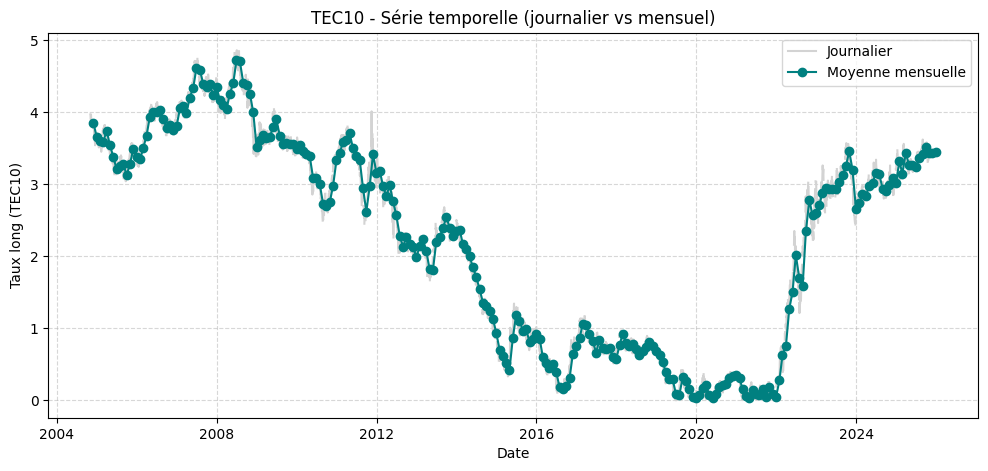

In [ ]:
# Construire le DataFrame avec tes arrays
ts_df = pd.DataFrame({
    "date": date_array,
    "TEC10": tec_array
})

# Convertir en datetime et mettre comme index
ts_df["date"] = pd.to_datetime(ts_df["date"])
ts_df = ts_df.set_index("date")

# --- Résampling mensuel ---
# Moyenne mensuelle
ts_monthly = ts_df.resample("ME").mean()
ts_meanj = ts_df.mean()

# Ecart-type mensuel
ts_monthly_std = ts_df.resample("ME").std()
ts_stdj = ts_df.std()

print("Moyenne stationnaire (mensuelle) :\n", ts_monthly)
print("Ecart-type stationnaire (mensuel) :\n", ts_monthly_std)
print("Moyenne stationnaire (jour) :\n", ts_meanj)
print("Ecart-type stationnaire (jour) :\n", ts_stdj)

# --- Visualisation ---
plt.figure(figsize=(12,5))
plt.plot(ts_df.index, ts_df["TEC10"], color="lightgray", label="Journalier")
plt.plot(ts_monthly.index, ts_monthly["TEC10"], color="teal", marker="o", label="Moyenne mensuelle")
plt.title("TEC10 - Série temporelle (journalier vs mensuel)")
plt.xlabel("Date")
plt.ylabel("Taux long (TEC10)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


Moyenne annuelle

/tmp/ipython-input-3280181223.py:13: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  ts_yearly = ts_df.resample("Y").mean()
/tmp/ipython-input-3280181223.py:16: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  ts_yearly_std = ts_df.resample("Y").std()


Moyenne stationnaire (annuelle) :
                TEC10
date                
2004-12-31  3.745581
2005-12-31  3.402812
2006-12-31  3.795137
2007-12-31  4.300859
2008-12-31  4.248911
2009-12-31  3.638809
2010-12-31  3.119217
2011-12-31  3.300868
2012-12-31  2.519773
2013-12-31  2.209518
2014-12-31  1.637631
2015-12-31  0.831289
2016-12-31  0.459366
2017-12-31  0.794016
2018-12-31  0.752906
2019-12-31  0.259357
2020-12-31  0.189117
2021-12-31  0.112868
2022-12-31  1.673619
2023-12-31   3.00937
2024-12-31  2.972062
2025-12-31  3.350851
Ecart-type stationnaire (annuel) :
                TEC10
date                
2004-12-31  0.123352
2005-12-31  0.188249
2006-12-31  0.211533
2007-12-31  0.201005
2008-12-31  0.331035
2009-12-31  0.134819
2010-12-31  0.302441
2011-12-31  0.335298
2012-12-31  0.404190
2013-12-31  0.226426
2014-12-31  0.443257
2015-12-31  0.235176
2016-12-31  0.226492
2017-12-31  0.163254
2018-12-31  0.085085
2019-12-31  0.193546
2020-12-31  0.114874
2021-12-31  0.085857
2022-

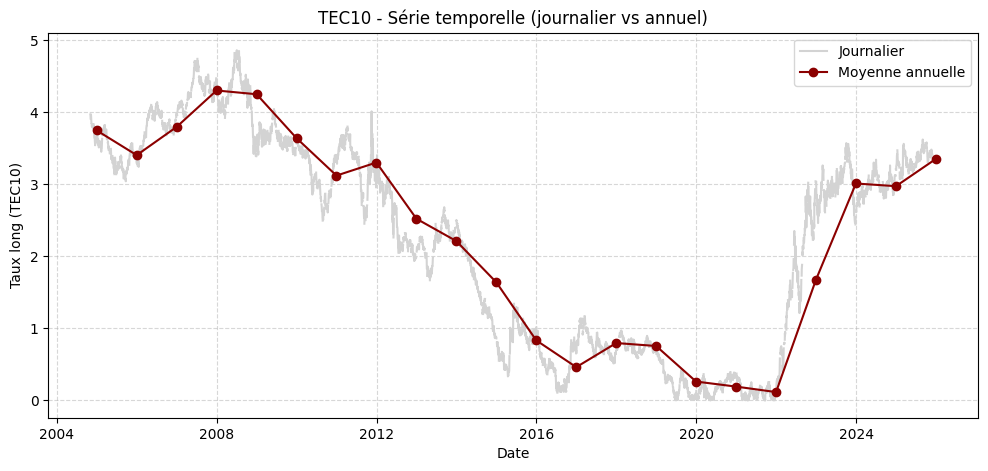

In [ ]:
# Construire le DataFrame avec tes arrays
ts_df = pd.DataFrame({
    "date": date_array,
    "TEC10": tec_array
})

# Convertir en datetime et mettre comme index
ts_df["date"] = pd.to_datetime(ts_df["date"])
ts_df = ts_df.set_index("date")

# --- Résampling annuel ---
# Moyenne annuelle
ts_yearly = ts_df.resample("Y").mean()

# Ecart-type annuel
ts_yearly_std = ts_df.resample("Y").std()

print("Moyenne stationnaire (annuelle) :\n", ts_yearly)
print("Ecart-type stationnaire (annuel) :\n", ts_yearly_std)

# --- Visualisation ---
plt.figure(figsize=(12,5))
plt.plot(ts_df.index, ts_df["TEC10"], color="lightgray", label="Journalier")
plt.plot(ts_yearly.index, ts_yearly["TEC10"], color="darkred", marker="o", label="Moyenne annuelle")
plt.title("TEC10 - Série temporelle (journalier vs annuel)")
plt.xlabel("Date")
plt.ylabel("Taux long (TEC10)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Vol locale - OAT10ans
- Importer les données historiques TEC10 (journalier ou mensuel).
- Convertir en série temporelle avec pandas.
- Résampler en mensuel (car Solveo travaille souvent en pas mensuel).
- Ajuster un modèle AR(1) sur la série mensuelle.
- Estimer a et \sigma .
- Déduire la volatilité locale.


Méthode 1 - estimation à partir de Rn

In [ ]:
# Construire le DataFrame avec tes arrays
ts_df = pd.DataFrame({
    "date": date_array,
    "TEC10": tec_array
})

# Convertir la colonne "date" en datetime
ts_df["date"] = pd.to_datetime(ts_df["date"])

# Mettre la colonne "date" comme index
ts_df = ts_df.set_index("date")

# Supprimer les NaN
ts_monthly = ts_df["TEC10"]
# ts_monthly = ts_monthly.dropna()

# Centrer la série autour de sa moyenne
y = ts_monthly.values.astype(float)   # conversion explicite en float

# Créer les variables pour AR(1)
Y_t = y[1:]        # valeurs à partir du 2e mois
Y_t_minus1 = y[:-1]   # valeurs décalées
d = 0.02

# Ajuster AR(1)
# X = sm.add_constant(Y_t_minus1)  # ajoute constante b
# model = sm.OLS(Y_t, X).fit()

sigma_stat = np.std(ts_df["TEC10"])
moy_stat = np.mean(ts_df["TEC10"])

print("sigma_stat :", sigma_stat)
print("moy_stat :", moy_stat)

# Calcul des différences d'une période à l'autre
diffs = np.log(Y_t_minus1+d)-np.log(Y_t+d)

# Volatilité locale = écart-type des différences
vol_localdiff = diffs.std()*np.sqrt(12)

print("Volatilité locale estimée via diff :", vol_localdiff)


sigma_stat : 0.014837014289049618
moy_stat : 0.021652862903225795
Volatilité locale estimée via diff : 0.20084429068170365
